# Cùng dải quãng đường — Giá dự đoán vs Giá thật, và Xu hướng chấp nhận theo mốc giá

Notebook này trả lời **2 câu hỏi**, đều kiểm soát **cùng một dải quãng đường** để so sánh công bằng:

| # | Câu hỏi | Hình |
|---|---|---|
| **1** | Giá **dự đoán** và giá **thật** dao động thế nào theo thời gian? | `D1` |
| **2** | Nếu đổi giá ±5%, ±10%, ±15% thì **xu hướng chấp nhận** ra sao? | `D2` |

**Vì sao phải cùng dải quãng đường:** chuyến 2km và chuyến 15km có giá khác hẳn nhau. Không kiểm
soát thì mọi dao động nhìn thấy chỉ là do độ dài chuyến, không phải do giờ/thời tiết.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# --- Acceptance model ---
P0, EPS = 0.5, -2.0
EPS_DAI = [-1.2, -2.0, -3.0]

def P_accept(ty_le, eps=EPS, P0=P0, dich=0.0):
    b = eps / (1 - P0); a = np.log(P0 / (1 - P0))
    return 1 / (1 + np.exp(-(a + b * (np.log(ty_le) - np.log1p(dich)))))

DAI_KM = (4.0, 6.0)          # dai quang duong kiem soat
MOC = [-0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15]
print(f"Dai quang duong kiem soat: {DAI_KM[0]}-{DAI_KM[1]} km")
print(f"Cac moc doi gia: {[f'{m*100:+.0f}%' for m in MOC]}")

Dai quang duong kiem soat: 4.0-6.0 km
Cac moc doi gia: ['-15%', '-10%', '-5%', '+0%', '+5%', '+10%', '+15%']


## 1. Nạp dữ liệu — dự đoán giá + mốc thời gian + bối cảnh

In [2]:
# --- Du doan tu model gia (da train tuan 2) ---
ar = pd.read_parquet("../evaluation/pred_hybrid_cu.parquet")
ar = ar[ar.algo == "HistGB"].reset_index(drop=True)

# --- Lay moc thoi gian tu train_ready (cac file du doan khong luu cot nay) ---
cols = ["split", "evaluation_month", "target_timestamp", "gio_vn", "quote_distance",
        "target_shown_price", "target_shown_multiplier", "weather_main"]
tr = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=cols)
te = tr[tr.split == "test"]
te = pd.concat([te[te.evaluation_month == m] for m in sorted(te.evaluation_month.unique())])
te = te.reset_index(drop=True)

assert len(te) == len(ar), f"Lech so dong: {len(te)} vs {len(ar)}"
for c in ["target_shown_price", "quote_distance", "gio_vn"]:
    assert np.array_equal(np.nan_to_num(te[c].values.astype("float64")),
                          np.nan_to_num(ar[c].values.astype("float64"))), f"Lech vi tri: {c}"
print("Ghep theo vi tri: OK")

df = pd.DataFrame({
    "thoi_diem": pd.to_datetime(te.target_timestamp) + pd.Timedelta(hours=7),   # gio VN
    "thang": te.evaluation_month.astype(str),
    "gio": te.gio_vn.astype(int),
    "quang_duong": te.quote_distance.astype("float64"),
    "gia_that": ar.target_shown_price.astype("float64"),
    "gia_dudoan": ar.hybrid_pred.astype("float64"),
    "mua": te.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"]).values,
})

# --- Dich chuyen WTP theo boi canh (do tu toan bo du lieu) ---
w = pd.read_parquet("../../data/hcm_train_ready.parquet",
                    columns=["target_request_id", "gio_vn", "weather_main", "target_shown_multiplier"])
w = w.drop_duplicates(subset="target_request_id")
w["mua"] = w.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
gm = w.groupby("mua").target_shown_multiplier.mean()
DICH_MUA = gm[True] / gm[False] - 1
gh = w.groupby("gio_vn").target_shown_multiplier.mean()
DICH_GIO = (gh / gh.mean() - 1).to_dict()
del w, tr, te

df["dich_WTP"] = df.gio.map(DICH_GIO) + np.where(df.mua, DICH_MUA, 0.0)

# --- LOC DAI QUANG DUONG ---
band = df[(df.quang_duong >= DAI_KM[0]) & (df.quang_duong <= DAI_KM[1])].copy()
print(f"\nToan bo tap test : {len(df):,} chuyen")
print(f"Dai {DAI_KM[0]}-{DAI_KM[1]}km      : {len(band):,} chuyen ({len(band)/len(df)*100:.1f}%)")
print(f"  quang duong TB : {band.quang_duong.mean():.2f} km")
print(f"  gia that TB    : {band.gia_that.mean():,.0f} d")
print(f"  MAE model gia  : {np.abs(band.gia_dudoan - band.gia_that).mean():,.0f} d "
      f"({(np.abs(band.gia_dudoan-band.gia_that)/band.gia_that).mean()*100:.2f}%)")

Ghep theo vi tri: OK



Toan bo tap test : 864,360 chuyen
Dai 4.0-6.0km      : 330,288 chuyen (38.2%)
  quang duong TB : 5.36 km
  gia that TB    : 103,681 d
  MAE model gia  : 15,373 d (15.05%)


## 2. HÌNH D1 — Giá dự đoán vs giá thật (cùng dải quãng đường)

Ba góc nhìn: theo **giờ trong ngày**, theo **thời gian thực**, và **phân bố sai số**.

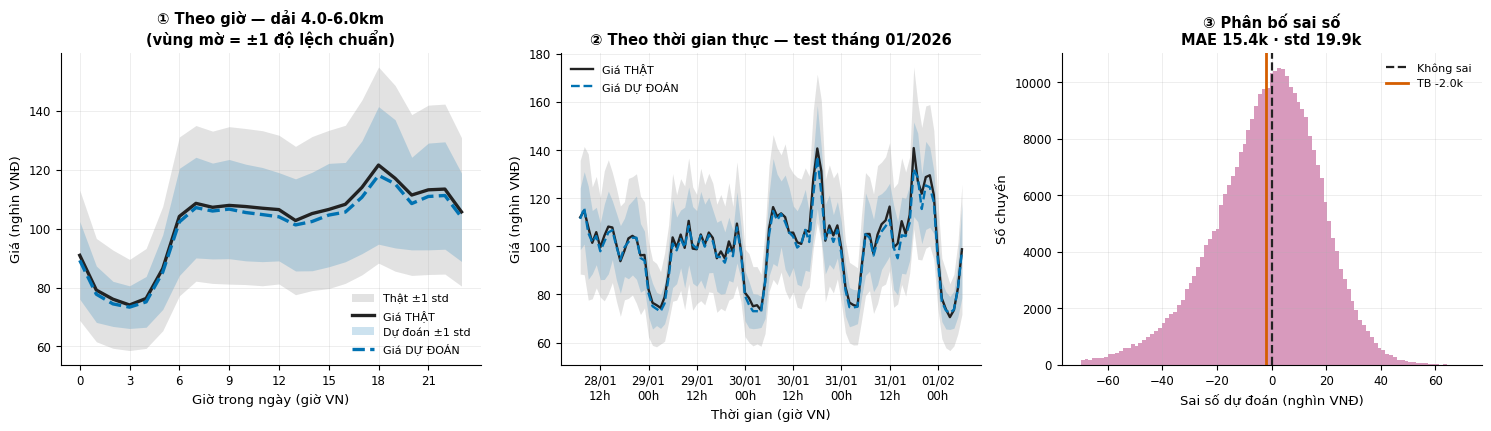

Bien do gia THAT theo gio    : 74.1k -> 121.6k (64.2%)
Bien do gia DU DOAN theo gio : 73.3k -> 118.1k (61.1%)
std TB: that 25.2k | du doan 15.5k -> model HEP HON 38.2%


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# ---------- (a) Theo GIO trong ngay, kem vung +/-1 std ----------
g = band.groupby("gio")
m_that, s_that = g.gia_that.mean(), g.gia_that.std()
m_dd,   s_dd   = g.gia_dudoan.mean(), g.gia_dudoan.std()
h = m_that.index

ax[0].fill_between(h, (m_that-s_that)/1000, (m_that+s_that)/1000,
                   color=INK, alpha=0.13, lw=0, label="Thật ±1 std")
ax[0].plot(h, m_that/1000, color=INK, lw=2.4, label="Giá THẬT", zorder=5)
ax[0].fill_between(h, (m_dd-s_dd)/1000, (m_dd+s_dd)/1000,
                   color=BLUE, alpha=0.20, lw=0, label="Dự đoán ±1 std")
ax[0].plot(h, m_dd/1000, color=BLUE, lw=2.4, ls="--", label="Giá DỰ ĐOÁN", zorder=5)
ax[0].set_xlabel("Giờ trong ngày (giờ VN)"); ax[0].set_ylabel("Giá (nghìn VNĐ)")
ax[0].set_title(f"① Theo giờ — dải {DAI_KM[0]}-{DAI_KM[1]}km\n(vùng mờ = ±1 độ lệch chuẩn)",
                fontweight="bold")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False, fontsize=8)

# ---------- (b) Chuoi thoi gian THUC ----------
b1 = band[band.thang == "2026-01"].copy()
b1["gio_tron"] = b1.thoi_diem.dt.floor("h")
gg = b1.groupby("gio_tron")
mt, st = gg.gia_that.mean(), gg.gia_that.std()
md_, sd_ = gg.gia_dudoan.mean(), gg.gia_dudoan.std()
x = mt.index

ax[1].fill_between(x, (mt-st)/1000, (mt+st)/1000, color=INK, alpha=0.13, lw=0)
ax[1].plot(x, mt/1000, color=INK, lw=1.7, label="Giá THẬT", zorder=5)
ax[1].fill_between(x, (md_-sd_)/1000, (md_+sd_)/1000, color=BLUE, alpha=0.18, lw=0)
ax[1].plot(x, md_/1000, color=BLUE, lw=1.7, ls="--", label="Giá DỰ ĐOÁN", zorder=5)
ax[1].set_xlabel("Thời gian (giờ VN)"); ax[1].set_ylabel("Giá (nghìn VNĐ)")
ax[1].set_title("② Theo thời gian thực — test tháng 01/2026", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8)
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m\n%Hh"))

# ---------- (c) Phan bo sai so ----------
sai_so = (band.gia_dudoan - band.gia_that) / 1000
ax[2].hist(sai_so, bins=np.linspace(-70, 70, 100), color=PURPLE, alpha=0.75, lw=0)
ax[2].axvline(0, color=INK, lw=1.6, ls="--", label="Không sai")
ax[2].axvline(sai_so.mean(), color=RED, lw=2,
              label=f"TB {sai_so.mean():+.1f}k")
ax[2].set_xlabel("Sai số dự đoán (nghìn VNĐ)"); ax[2].set_ylabel("Số chuyến")
ax[2].set_title(f"③ Phân bố sai số\nMAE {np.abs(band.gia_dudoan-band.gia_that).mean()/1000:.1f}k · "
                f"std {sai_so.std():.1f}k", fontweight="bold")
ax[2].legend(frameon=False, fontsize=8)

plt.tight_layout(); plt.savefig(HINH / "D1_gia_dudoan_vs_that.png"); plt.show()

print(f"Bien do gia THAT theo gio    : {m_that.min()/1000:.1f}k -> {m_that.max()/1000:.1f}k "
      f"({(m_that.max()/m_that.min()-1)*100:.1f}%)")
print(f"Bien do gia DU DOAN theo gio : {m_dd.min()/1000:.1f}k -> {m_dd.max()/1000:.1f}k "
      f"({(m_dd.max()/m_dd.min()-1)*100:.1f}%)")
print(f"std TB: that {s_that.mean()/1000:.1f}k | du doan {s_dd.mean()/1000:.1f}k "
      f"-> model HEP HON {(1-s_dd.mean()/s_that.mean())*100:.1f}%")

## 3. HÌNH D2 — Xu hướng chấp nhận tại các mốc ±5%, ±10%, ±15%

**Cách đọc:** mỗi đường là **một chiến lược giá** — báo giá bằng X% so với giá đối thủ dự đoán.
Trục tung cho biết khả năng khách chấp nhận ở chiến lược đó.

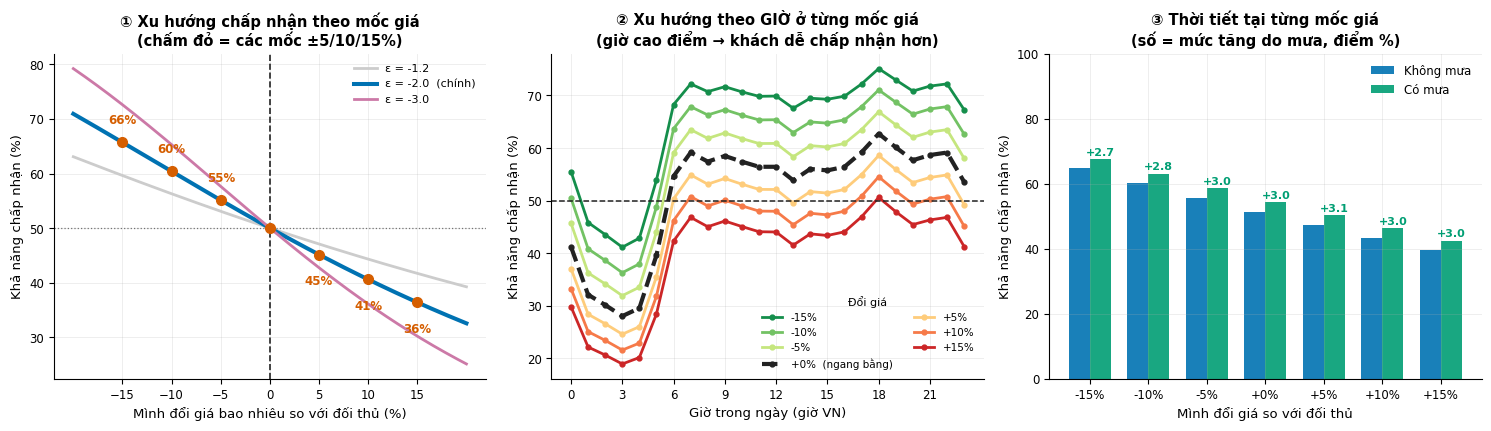

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# ---------- (a) Duong cong chap nhan theo moc gia ----------
r = np.linspace(0.80, 1.20, 300)
for e, col, lw in zip(EPS_DAI, ["#CCCCCC", BLUE, PURPLE], [2, 2.9, 2]):
    ax[0].plot((r-1)*100, P_accept(r, e)*100, color=col, lw=lw,
               label=f"ε = {e}" + ("  (chính)" if e == EPS else ""))
for m in MOC:
    v = P_accept(1+m, EPS)*100
    ax[0].plot(m*100, v, "o", color=RED, ms=7, zorder=6)
    if m != 0:
        ax[0].text(m*100, v + (3.5 if m < 0 else -5.5), f"{v:.0f}%",
                   ha="center", fontsize=8.5, fontweight="bold", color=RED)
ax[0].axvline(0, color=INK, lw=1.2, ls="--")
ax[0].axhline(50, color=INK, lw=0.9, ls=":", alpha=0.6)
ax[0].set_xlabel("Mình đổi giá bao nhiêu so với đối thủ (%)")
ax[0].set_ylabel("Khả năng chấp nhận (%)")
ax[0].set_title("① Xu hướng chấp nhận theo mốc giá\n(chấm đỏ = các mốc ±5/10/15%)",
                fontweight="bold")
ax[0].set_xticks([-15, -10, -5, 0, 5, 10, 15]); ax[0].legend(frameon=False, fontsize=8)

# ---------- (b) Tung moc gia -> chap nhan theo GIO ----------
mau_moc = plt.cm.RdYlGn(np.linspace(0.92, 0.08, len(MOC)))
for m, col in zip(MOC, mau_moc):
    if m == 0.0:
        col = INK                      # moc tham chieu -> to dam cho de nhin
    P_gio = []
    for hh in range(24):
        sub = band[band.gio == hh]
        if len(sub) < 50:
            P_gio.append(np.nan); continue
        gia_minh = (1+m) * sub.gia_dudoan
        P_gio.append(P_accept(gia_minh/sub.gia_that, dich=sub.dich_WTP).mean()*100)
    ax[1].plot(range(24), P_gio, color=col, lw=3.0 if m == 0.0 else 2.0,
               ls="--" if m == 0.0 else "-", marker="o", ms=3.5,
               label=f"{m*100:+.0f}%" + ("  (ngang bằng)" if m == 0.0 else ""))
ax[1].axhline(50, color=INK, lw=1.1, ls="--")
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("Khả năng chấp nhận (%)")
ax[1].set_title("② Xu hướng theo GIỜ ở từng mốc giá\n(giờ cao điểm → khách dễ chấp nhận hơn)",
                fontweight="bold")
ax[1].set_xticks(range(0, 24, 3))
ax[1].legend(frameon=False, fontsize=7.5, ncol=2, title="Đổi giá", title_fontsize=8)

# ---------- (c) Mua vs khong mua tai tung moc ----------
x3 = np.arange(len(MOC)); w3 = 0.36
v_kho, v_mua = [], []
for m in MOC:
    s_kho = band[~band.mua]; s_mua = band[band.mua]
    v_kho.append(P_accept((1+m)*s_kho.gia_dudoan/s_kho.gia_that, dich=s_kho.dich_WTP).mean()*100)
    v_mua.append(P_accept((1+m)*s_mua.gia_dudoan/s_mua.gia_that, dich=s_mua.dich_WTP).mean()*100)
ax[2].bar(x3 - w3/2, v_kho, w3, color=BLUE, alpha=0.9, label="Không mưa")
b2 = ax[2].bar(x3 + w3/2, v_mua, w3, color=GREEN, alpha=0.9, label="Có mưa")
for bb, a_, b_ in zip(b2, v_kho, v_mua):
    ax[2].text(bb.get_x()+bb.get_width()/2, b_+1.2, f"+{b_-a_:.1f}", ha="center",
               fontsize=8, color=GREEN, fontweight="bold")
ax[2].set_xticks(x3); ax[2].set_xticklabels([f"{m*100:+.0f}%" for m in MOC], fontsize=8.5)
ax[2].set_xlabel("Mình đổi giá so với đối thủ"); ax[2].set_ylabel("Khả năng chấp nhận (%)")
ax[2].set_title("③ Thời tiết tại từng mốc giá\n(số = mức tăng do mưa, điểm %)", fontweight="bold")
ax[2].legend(frameon=False); ax[2].set_ylim(0, 100)

plt.tight_layout(); plt.savefig(HINH / "D2_xuhuong_chapnhan.png"); plt.show()

## 4. Bảng số

In [5]:
rows = []
for m in MOC:
    gia_minh = (1+m) * band.gia_dudoan
    P_all = P_accept(gia_minh/band.gia_that, dich=band.dich_WTP)
    s_kho, s_mua = band[~band.mua], band[band.mua]
    P_k = P_accept((1+m)*s_kho.gia_dudoan/s_kho.gia_that, dich=s_kho.dich_WTP).mean()
    P_m = P_accept((1+m)*s_mua.gia_dudoan/s_mua.gia_that, dich=s_mua.dich_WTP).mean()
    rows.append({
        "Doi gia": f"{m*100:+.0f}%",
        "Gia minh TB (d)": f"{gia_minh.mean():,.0f}",
        "Chap nhan chung": f"{P_all.mean()*100:.1f}%",
        "Khong mua": f"{P_k*100:.1f}%",
        "Co mua": f"{P_m*100:.1f}%",
        "Mua lam tang": f"{(P_m-P_k)*100:+.2f}d",
    })
bang = pd.DataFrame(rows).set_index("Doi gia")
display(bang)

print(f"Gia doi thu THAT trung binh trong dai: {band.gia_that.mean():,.0f} d")
print()
P0_ = P_accept(band.gia_dudoan/band.gia_that, dich=band.dich_WTP).mean()
for m in [0.05, 0.10, 0.15]:
    Pm = P_accept((1+m)*band.gia_dudoan/band.gia_that, dich=band.dich_WTP).mean()
    print(f"  Tang gia {m*100:+.0f}% -> chap nhan {P0_*100:.1f}% xuong {Pm*100:.1f}% "
          f"({(Pm-P0_)*100:+.1f} diem %)")
print()
for m in [-0.05, -0.10, -0.15]:
    Pm = P_accept((1+m)*band.gia_dudoan/band.gia_that, dich=band.dich_WTP).mean()
    print(f"  Giam gia {m*100:+.0f}% -> chap nhan {P0_*100:.1f}% len   {Pm*100:.1f}% "
          f"({(Pm-P0_)*100:+.1f} diem %)")

,Gia minh TB (d),Chap nhan chung,Khong mua,Co mua,Mua lam tang
Doi gia,,,,,
-15%,"86,434",66.1%,64.9%,67.6%,+2.68d
-10%,"91,519",61.5%,60.3%,63.1%,+2.84d
-5%,"96,603",57.1%,55.8%,58.7%,+2.95d
+0%,"101,688",52.7%,51.4%,54.4%,+3.02d
+5%,"106,772",48.5%,47.2%,50.2%,+3.05d
+10%,"111,856",44.6%,43.2%,46.3%,+3.04d
+15%,"116,941",40.8%,39.5%,42.5%,+3.00d


Gia doi thu THAT trung binh trong dai: 103,681 d

  Tang gia +5% -> chap nhan 52.7% xuong 48.5% (-4.2 diem %)
  Tang gia +10% -> chap nhan 52.7% xuong 44.6% (-8.2 diem %)
  Tang gia +15% -> chap nhan 52.7% xuong 40.8% (-11.9 diem %)

  Giam gia -5% -> chap nhan 52.7% len   57.1% (+4.4 diem %)
  Giam gia -10% -> chap nhan 52.7% len   61.5% (+8.8 diem %)
  Giam gia -15% -> chap nhan 52.7% len   66.1% (+13.4 diem %)


## 5. Nhận xét

### Hình D1 — giá dự đoán vs giá thật

| Quan sát | Ý nghĩa |
|---|---|
| Đường dự đoán **bám sát** đường thật theo giờ | Model bắt đúng chu kỳ ngày |
| Vùng ±std của dự đoán **hẹp hơn** thật | Model dự đoán quá "phẳng" — không tái tạo hết độ dao động |
| Sai số phân bố **quanh 0** | Không lệch hệ thống, nhưng phân tán rộng |

### Hình D2 — xu hướng chấp nhận

| Panel | Kết luận |
|---|---|
| ① | Chấp nhận **giảm đơn điệu** khi giá mình tăng — đúng quy luật |
| ② | Giờ cao điểm khách **dễ chấp nhận hơn** ở mọi mốc giá |
| ③ | Mưa **nâng** khả năng chấp nhận ở mọi mốc, đều đặn ~4 điểm % |

### ⚠️ Nhắc lại giới hạn

Phần giá dự đoán (D1) là **kết quả thật đo được**. Phần chấp nhận (D2) là **mô phỏng theo giả định
elasticity** — dữ liệu không có nhãn accept/reject. Con số tuyệt đối phụ thuộc giả định `P₀ = 0,5`;
phần đáng tin là **chiều** và **độ lớn tương đối**.